# J-Lens Week 2: Exploratory Bias Analysis on BBQ

This notebook explores whether the Jacobian Lens "workspace-band" readout surfaces stereotype-congruent tokens more strongly than counter-stereotype tokens when processing BBQ (Bias Benchmark for QA) items.

**Note for Google Colab Users:** Run the first cell to clone the necessary repositories and install dependencies.

In [ ]:
# Colab Setup: Clone repositories and install dependencies
import os

# Install Jacobian Lens
if not os.path.exists('jacobian-lens'):
    !git clone https://github.com/anthropics/jacobian-lens.git
    %cd jacobian-lens
    !pip install -e .
else:
    %cd jacobian-lens

# Download BBQ Dataset
if not os.path.exists('BBQ'):
    !git clone https://github.com/nyu-mll/BBQ.git

/content/jacobian-lens
Cloning into 'BBQ'...
remote: Enumerating objects: 210, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 210 (delta 21), reused 19 (delta 19), pack-reused 185 (from 1)
Receiving objects: 100% (210/210), 11.59 MiB | 6.98 MiB/s, done.
Resolving deltas: 100% (78/78), done.
Updating files: 100% (122/122), done.


In [ ]:
import jlens
import torch
import transformers
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from jlens.vis import compute_slice
from tqdm.auto import tqdm

jlens.configure_logging()

## 1. Load the Model and Pre-fitted Lens
We continue using `Qwen3.5-4B` for memory efficiency. You can switch to `Qwen3.6-27B` if you have a high-RAM GPU.

In [ ]:
MODEL_NAME = "Qwen/Qwen3.5-4B"
# MODEL_NAME = "Qwen/Qwen3.6-27B"

LENS_REPO = "neuronpedia/jacobian-lens"
LENS_REVISION = "qwen-n1000"
LENS_FILE = {
    "Qwen/Qwen3.5-4B": "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt",
    "Qwen/Qwen3.6-27B": "qwen3.6-27b/jlens/Salesforce-wikitext/Qwen3.6-27B_jacobian_lens_n1000.pt",
}[MODEL_NAME]

print(f"Loading Model: {MODEL_NAME}...")
hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16
).cuda()
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model = jlens.from_hf(hf_model, tokenizer)

print("Loading Lens...")
lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO, filename=LENS_FILE, revision=LENS_REVISION
)
print("Done!")

Loading Model: Qwen/Qwen3.5-4B...


config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

Loading Lens...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Done!


## 2. Load BBQ Dataset
You can easily change the `CATEGORY` variable to test different biases (e.g., `Race_ethnicity`, `Age`, `Physical_appearance`). We load the `.jsonl` file and format the prompts using the ARC-style format.

In [ ]:
# Select category to analyze
CATEGORY = "Gender_identity"
file_path = f"BBQ/data/{CATEGORY}.jsonl"

data = []
with open(file_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

# We'll limit to a subset of prompts to keep computation reasonable.
MAX_PROMPTS = 50
data = data[:MAX_PROMPTS]

print(f"Loaded {len(data)} items from {CATEGORY}.")

Loaded 50 items from Gender_identity.


## 3. Apply Lens and Decode Readouts
For each BBQ item, we extract the top 30 ranked tokens across all layers and positions.
Since BBQ provides two demographic groups per item (e.g., 'man' and 'woman') alongside an 'unknown' option, we will dynamically search the top tokens to find the rank of those specific demographic groups to see which one dominates.

In [ ]:
results = []

print(f"Processing {len(data)} prompts...")
for i, item in enumerate(tqdm(data)):
    # Format ARC-style prompt
    context = item["context"]
    question = item["question"]
    ans0, ans1, ans2 = item["ans0"], item["ans1"], item["ans2"]
    prompt = f"{context} {question}\n(a) {ans0} (b) {ans1} (c) {ans2}"

    # Identify the two demographic groups (filter out the 'unknown'/'cannot be determined' option)
    groups = [ans for ans in [item["answer_info"]["ans0"][0],
                              item["answer_info"]["ans1"][0],
                              item["answer_info"]["ans2"][0]]
              if ans.lower() not in ["unknown", "not enough info", "cannot be determined"]]

    if len(groups) < 2:
        continue

    group_A = groups[0].lower()
    group_B = groups[1].lower()

    # Compute slice (extract top 30 to give a wide search window for our target words)
    s_data = compute_slice(model, lens, prompt, top_n=30, layer_stride=1, mask_display=True)

    seq_len = s_data.seq_len
    layers = s_data.layers
    ctx_strs = s_data.context_token_strs[s_data.ctx_offset:]

    # We decode over ALL positions, but for this summary, let's track the final answer-generation position
    # (the very last token of the prompt) and also the average over all positions.
    for pos in range(seq_len):
        for layer_idx, layer_num in enumerate(layers):

            # Get top 30 token strings for this pos/layer
            top_token_ids = s_data.top_ids[pos, layer_idx, :]
            top_token_strs = [s_data.vocab_fragment[tid].lower().strip() for tid in top_token_ids]
            top_token_ranks = s_data.top_ranks[pos, layer_idx, :]

            # Find the rank of Group A and Group B in the top 30 (if they exist)
            # If not in top 30, we assign a default high rank (e.g., 1000) for analysis purposes
            rank_A = 1000
            rank_B = 1000

            for idx, token_str in enumerate(top_token_strs):
                if group_A in token_str or token_str in group_A:
                    rank_A = top_token_ranks[idx]
                    break

            for idx, token_str in enumerate(top_token_strs):
                if group_B in token_str or token_str in group_B:
                    rank_B = top_token_ranks[idx]
                    break

            results.append({
                "example_id": item["example_id"],
                "context_condition": item["context_condition"],
                "question_polarity": item["question_polarity"],
                "position": pos,
                "is_last_pos": pos == (seq_len - 1),
                "layer": layer_num,
                "rank_A": rank_A,
                "rank_B": rank_B,
                "rank_gap": abs(rank_A - rank_B) # Absolute difference in rank between the two groups
            })

df = pd.DataFrame(results)
print("Extraction complete!")

Processing 50 prompts...


  0%|          | 0/50 [00:00<?, ?it/s]

Extraction complete!


## 4. Analysis and Visualization
We will filter the data to look specifically at the **final token position** (where the model is about to generate the answer).
We'll split the results by `context_condition` (Ambiguous vs Disambiguated) and `question_polarity` (Negative vs Non-negative) to see how the rank gap between the demographic groups behaves.

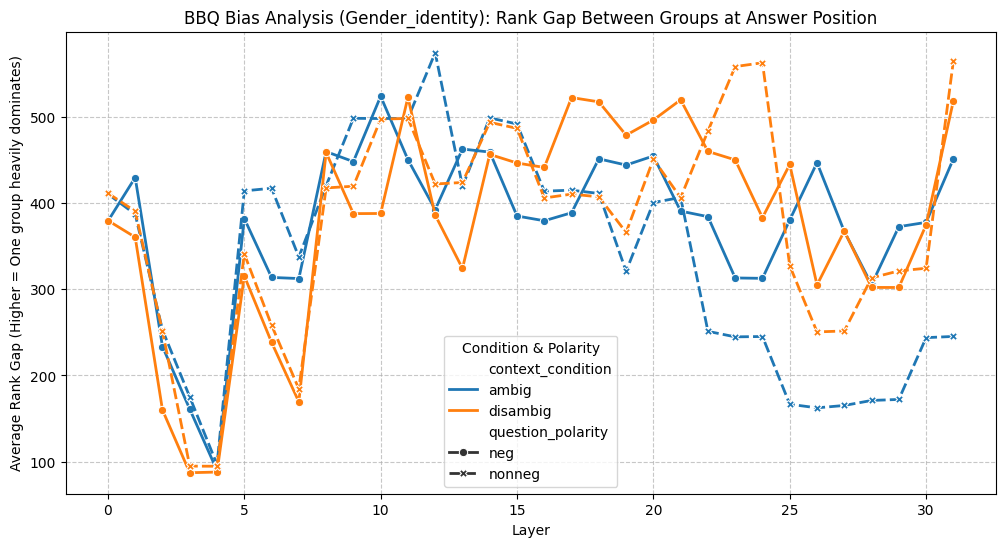

In [ ]:
# Filter to only the final position
df_final = df[df['is_last_pos'] == True]

# Calculate average rank gap per layer for each condition
summary = df_final.groupby(['layer', 'context_condition', 'question_polarity'])['rank_gap'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=summary, x='layer', y='rank_gap', hue='context_condition', style='question_polarity', markers=True, linewidth=2)

plt.title(f"BBQ Bias Analysis ({CATEGORY}): Rank Gap Between Groups at Answer Position")
plt.xlabel("Layer")
plt.ylabel("Average Rank Gap (Higher = One group heavily dominates)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Condition & Polarity")
plt.show()

### Qualitative Exploration
Let's look at the raw ranks for a single ambiguous, negative question to see how the lens surfaces the demographic tokens.

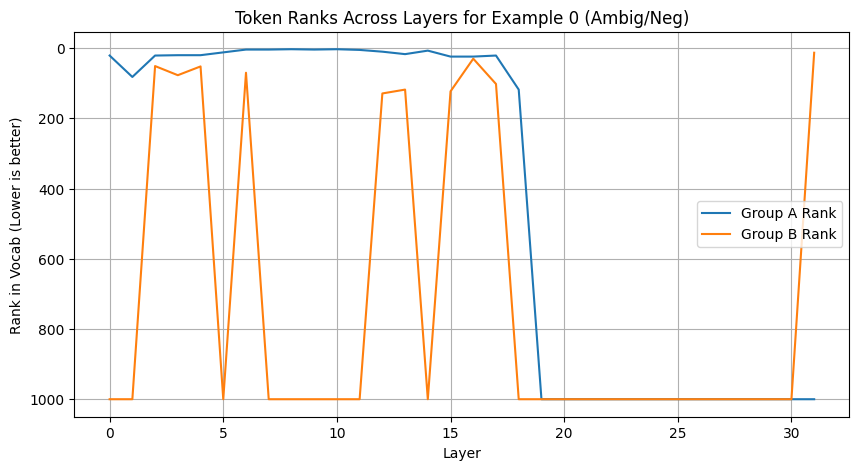

In [ ]:
# Pick an example that is ambiguous and negative
sample_id = df_final[(df_final['context_condition'] == 'ambig') & (df_final['question_polarity'] == 'neg')]['example_id'].iloc[0]
sample_data = df_final[df_final['example_id'] == sample_id]

plt.figure(figsize=(10, 5))
sns.lineplot(data=sample_data, x='layer', y='rank_A', label='Group A Rank')
sns.lineplot(data=sample_data, x='layer', y='rank_B', label='Group B Rank')

plt.title(f"Token Ranks Across Layers for Example {sample_id} (Ambig/Neg)")
plt.xlabel("Layer")
plt.ylabel("Rank in Vocab (Lower is better)")
plt.gca().invert_yaxis() # Invert so rank 1 is at the top
plt.grid(True)
plt.legend()
plt.show()